# 07 - Semiconductor Temperature Scaling (central result)
Junction temperature vs radiator area, mass, launch mass and launch cost. The T^-4 collapse dwarfs the bounded emissivity benefit.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
from models.future_chip_model.run import run
out = run(); sweep = out['sweep']; sweep.head()

,junction_temp_k,junction_temp_c,radiator_temp_k,radiator_area_m2,radiator_mass_kg,area_reduction_vs_coolest,total_mass_kg,deployment_cost_usd,cost_per_mw_usd
0,380.000000,106.850000,325.000000,92983.502303,650884.516122,1.000000,1.342551e+06,6.712756e+08,6.712756e+06
1,404.827586,131.677586,349.827586,69266.481849,484865.372945,1.342403,1.176532e+06,5.882660e+08,5.882660e+06
2,429.655172,156.505172,374.655172,52651.701707,368561.911952,1.766011,1.060229e+06,5.301143e+08,5.301143e+06
3,454.482759,181.332759,399.482759,40733.073609,285131.515266,2.282752,9.767982e+05,4.883991e+08,4.883991e+06
4,479.310345,206.160345,424.310345,32004.044248,224028.309733,2.905367,9.156950e+05,4.578475e+08,4.578475e+06


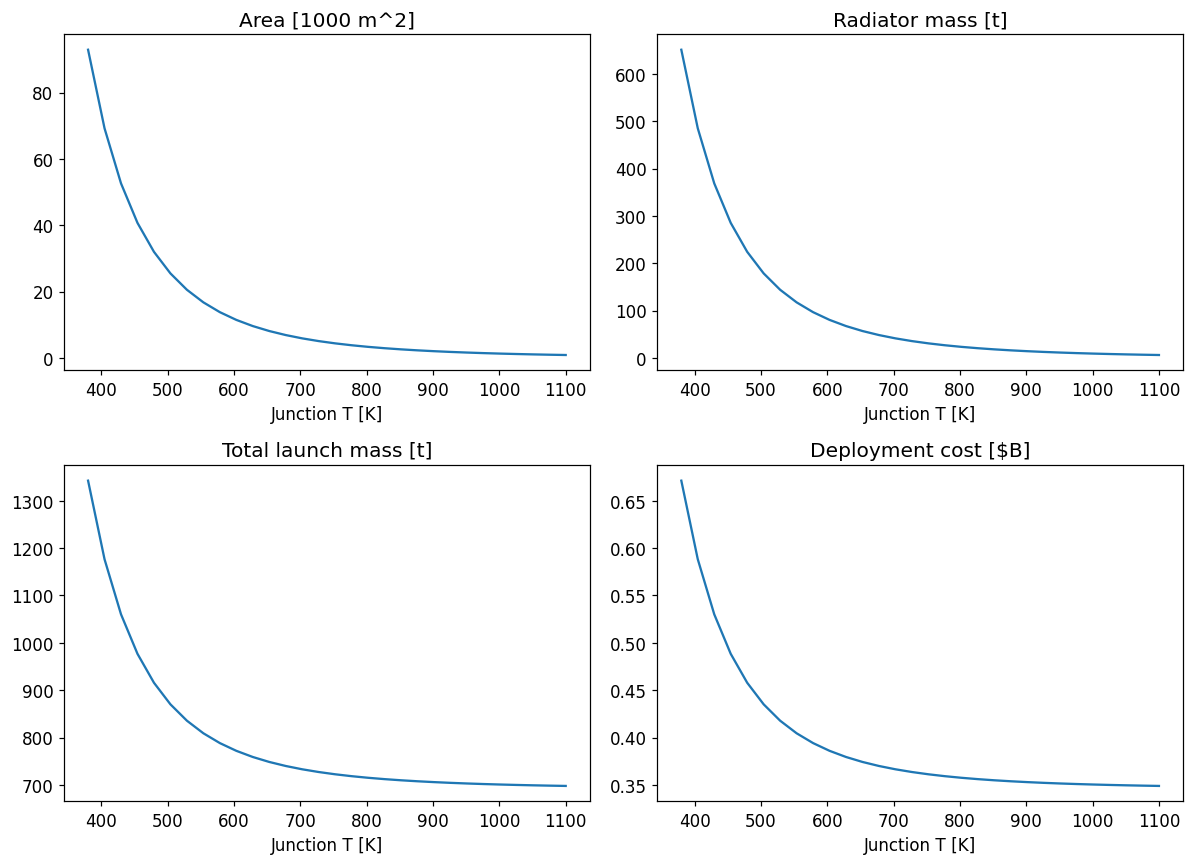

In [2]:
fig, ax = plt.subplots(2,2, figsize=(11,8))
ax[0,0].plot(sweep['junction_temp_k'], sweep['radiator_area_m2']/1e3); ax[0,0].set_title('Area [1000 m^2]')
ax[0,1].plot(sweep['junction_temp_k'], sweep['radiator_mass_kg']/1e3); ax[0,1].set_title('Radiator mass [t]')
ax[1,0].plot(sweep['junction_temp_k'], sweep['total_mass_kg']/1e3); ax[1,0].set_title('Total launch mass [t]')
ax[1,1].plot(sweep['junction_temp_k'], sweep['deployment_cost_usd']/1e9); ax[1,1].set_title('Deployment cost [$B]')
for a in ax.flat: a.set_xlabel('Junction T [K]')
plt.tight_layout(); plt.show()

In [3]:
out['material_table']

,Material,Bandgap [eV],k [W/m/K],Max Tj [K],Max Tj [C],Radiator T [K],Radiator area [m2],Radiator mass [kg],Rad tolerance,TRL,Mass vs silicon
0,Silicon (Si),1.12,150.0,398.0,124.85,343.0,74948.485874,524639.401115,moderate,9,1.000000
1,Gallium Nitride (GaN),3.40,160.0,573.0,299.85,518.0,14408.550844,100859.855905,high,7,0.192246
2,Silicon Carbide (4H-SiC),3.26,370.0,623.0,349.85,568.0,9966.576380,69766.034662,high,8,0.132979
3,Gallium Oxide (beta-Ga2O3),4.80,23.0,773.0,499.85,718.0,3903.386584,27323.706088,high,4,0.052081
4,Diamond semiconductor,5.47,2200.0,1073.0,799.85,1018.0,965.935728,6761.550096,very high,3,0.012888
